# Lab 06 — Wavelets, Boundary Detection, Hough Transform & SIFT (AI-4002)
*(the manual's cover says "Lab 05", but this is the 6th manual)*

| Section | What's inside |
|---|---|
| 0 | Setup — sample files + helpers |
| A | Wavelets: 2-D DWT (LL/LH/HL/HH), multi-level, inverse, denoising, CWT & WPT |
| B | Boundary detection: Sobel (worked 760 example), Canny, LoG |
| C | Hough lines (standard + probabilistic) and Hough circles |
| D | SIFT: keypoints, 128-D descriptors, matching (ratio test), RANSAC homography |
| **Lab-timing tasks** | T-A Screen detection (Hough lines) · T-B Asset tracking (SIFT) · T-C Sensor anomaly detection (wavelet) |
| **Lab tasks** | T-D Object recognition (SIFT + box, video-ready) · T-E Panorama (SIFT) · T-F Lane detection (Hough) · T-G Coin counting (Hough circles) · T-H Smart security zone (boundary detection on video) |

`pip install PyWavelets` gives `import pywt`.

## 0. Setup

In [1]:
import os, cv2, numpy as np, matplotlib.pyplot as plt, pywt
from skimage import data
os.makedirs('data', exist_ok=True); os.makedirs('output', exist_ok=True)
rng = np.random.default_rng(0)
if not os.path.exists('data/image.jpg'):
    cv2.imwrite('data/image.jpg', cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR))
if not os.path.exists('data/coins.png'):
    cv2.imwrite('data/coins.png', data.coins())

def show(images, titles, cols=None, size=4):
    cols = cols or len(images); rows = int(np.ceil(len(images) / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(size * cols, size * 0.8 * rows)); ax = np.array(ax).ravel()
    for a in ax: a.axis('off')
    for a, im, t in zip(ax, images, titles):
        a.imshow(im if im.ndim == 2 else cv2.cvtColor(im, cv2.COLOR_BGR2RGB), cmap='gray' if im.ndim == 2 else None); a.set_title(t, fontsize=10)
    plt.tight_layout(); plt.show()
print('ready; OpenCV', cv2.__version__, '| SIFT available:', hasattr(cv2, 'SIFT_create'))

ready; OpenCV 5.0.0 | SIFT available: True


# A. Wavelet transformation
Analyse a signal/image by **frequency components at different scales** (time-frequency analysis; good for non-stationary signals).
* **CWT** – continuous; wavelet ψ(t) dilated & translated (e.g. **Morlet**); seismic & image analysis.
* **DWT** – discrete scaling/shifting; families **Haar, Daubechies (db), Symlet**; compression, denoising, feature extraction.
* **WPT** – extends DWT: splits *detail* bands too (more subbands).
* **Inverse** – reconstruct from coefficients (compression, denoising).

2-D DWT gives 4 sub-bands: **LL** approximation, **LH** horizontal detail, **HL** vertical detail, **HH** diagonal detail (each half size).

input (512, 512) -> each sub-band (256, 256)


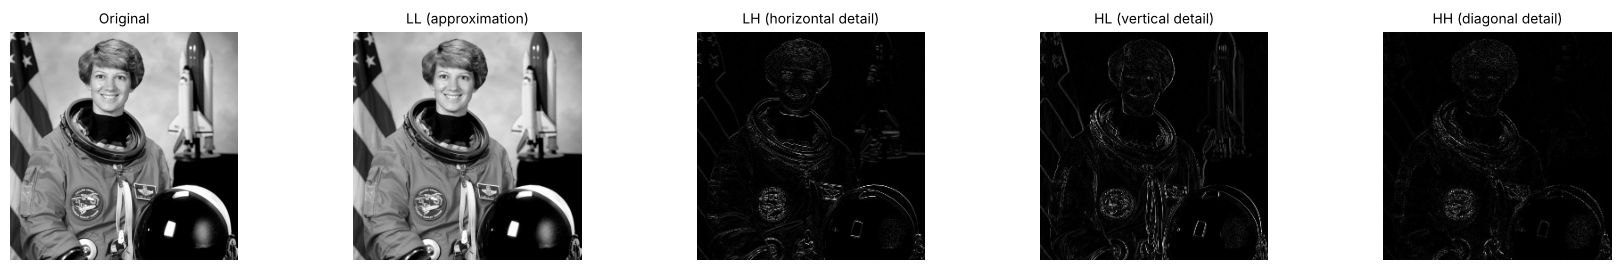

reconstruction max error: 6.103515625e-05


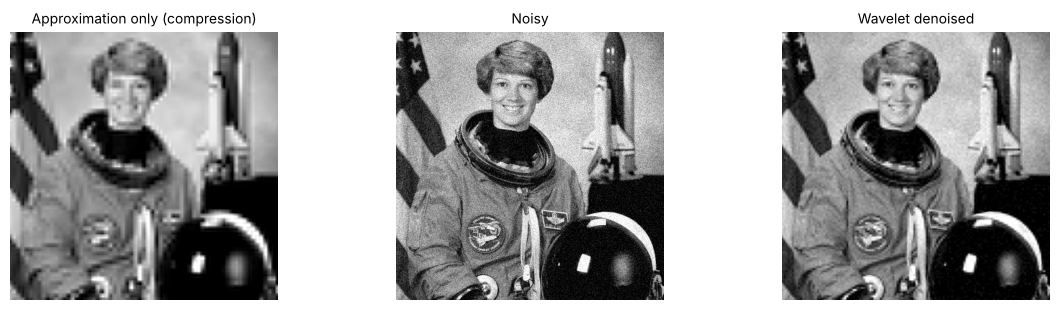

In [2]:
gray = cv2.imread('data/image.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float32)
LL, (LH, HL, HH) = pywt.dwt2(gray, 'haar')                       # one level
print('input', gray.shape, '-> each sub-band', LL.shape)
show([gray, LL, np.abs(LH), np.abs(HL), np.abs(HH)], ['Original', 'LL (approximation)', 'LH (horizontal detail)', 'HL (vertical detail)', 'HH (diagonal detail)'], size=3.5)

# inverse transform -> perfect reconstruction
rec = pywt.idwt2((LL, (LH, HL, HH)), 'haar')
print('reconstruction max error:', float(np.abs(rec - gray).max()))

# compression idea: keep only 3-level approximation (1/64 of coefficients)
coeffs = pywt.wavedec2(gray, 'db2', level=3)
approx_only = [coeffs[0]] + [tuple(np.zeros_like(d) for d in lvl) for lvl in coeffs[1:]]
compressed = pywt.waverec2(approx_only, 'db2')

# denoising: soft-threshold the detail coefficients
noisy = gray + rng.normal(0, 25, gray.shape)
c = pywt.wavedec2(noisy, 'db2', level=2)
sigma = np.median(np.abs(c[-1][-1])) / 0.6745                       # noise estimate from finest HH
thr = sigma * np.sqrt(2 * np.log(noisy.size))                       # universal threshold
den = pywt.waverec2([c[0]] + [tuple(pywt.threshold(d, thr, 'soft') for d in lvl) for lvl in c[1:]], 'db2')
show([np.clip(compressed, 0, 255), np.clip(noisy, 0, 255), np.clip(den, 0, 255)], ['Approximation only (compression)', 'Noisy', 'Wavelet denoised'], size=4)

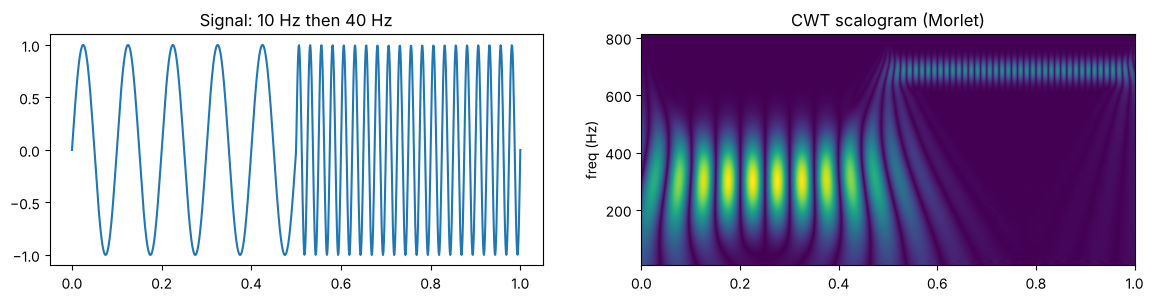

WPT level-3 nodes (all subbands): ['aaa', 'aad', 'ada', 'add', 'daa', 'dad', 'dda', 'ddd']


In [3]:
# 1-D CWT (Morlet) on a non-stationary signal: frequency changes over time
t = np.linspace(0, 1, 1000)
sig = np.where(t < 0.5, np.sin(2 * np.pi * 10 * t), np.sin(2 * np.pi * 40 * t))
scales = np.arange(1, 128)
cwt, freqs = pywt.cwt(sig, scales, 'morl', sampling_period=t[1] - t[0])
fig, ax = plt.subplots(1, 2, figsize=(14, 3))
ax[0].plot(t, sig); ax[0].set_title('Signal: 10 Hz then 40 Hz')
ax[1].imshow(np.abs(cwt), aspect='auto', extent=[0, 1, freqs[-1], freqs[0]]); ax[1].set_ylabel('freq (Hz)'); ax[1].set_title('CWT scalogram (Morlet)')
plt.show()
wp = pywt.WaveletPacket(data=sig, wavelet='db1', maxlevel=3)
print('WPT level-3 nodes (all subbands):', [n.path for n in wp.get_level(3, 'natural')])

# B. Boundary (edge) detection
**Sobel:** Gx = [[−1,0,1],[−2,0,2],[−1,0,1]] (horizontal change → **vertical** edges), Gy = [[−1,−2,−1],[0,0,0],[1,2,1]] (vertical change → **horizontal** edges). Magnitude G = √(Gx² + Gy²) = strength; direction = orientation. Use **CV_64F** to keep negative values.

vertical edge patch response Gx = 760.0   (= 800 - 40 = 760)
uniform patch response = 0.0   (= 200 - 200 = 0)


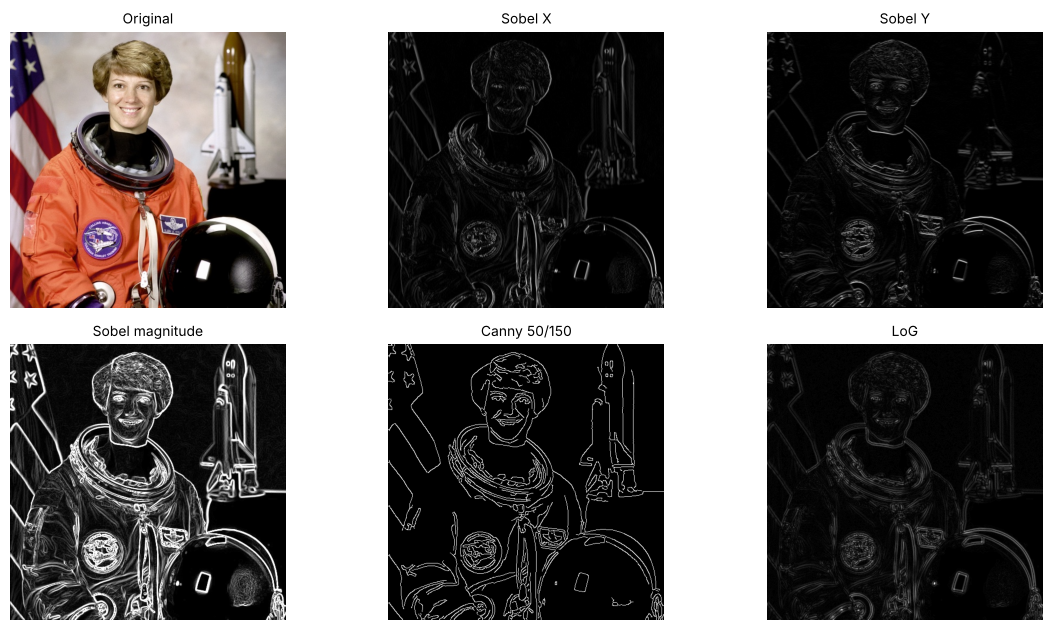

In [4]:
patch = np.array([[10, 10, 10, 200]] * 3, np.float64)
Gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], np.float64)
print('vertical edge patch response Gx =', np.sum(patch[:, 1:4] * Gx), '  (= 800 - 40 = 760)')
print('uniform patch response =', np.sum(np.full((3, 3), 50) * Gx), '  (= 200 - 200 = 0)')

image = cv2.imread('data/image.jpg'); g = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
sobel_x = cv2.Sobel(g, cv2.CV_64F, 1, 0, ksize=3); sobel_y = cv2.Sobel(g, cv2.CV_64F, 0, 1, ksize=3)
magnitude = np.uint8(np.clip(np.sqrt(sobel_x**2 + sobel_y**2), 0, 255))
blurred = cv2.GaussianBlur(g, (5, 5), 1.4)
canny = cv2.Canny(blurred, 50, 150)                                   # lower, upper
log = cv2.convertScaleAbs(cv2.Laplacian(blurred, cv2.CV_64F))         # LoG: Gaussian then Laplacian
show([image, np.abs(sobel_x), np.abs(sobel_y), magnitude, canny, log], ['Original', 'Sobel X', 'Sobel Y', 'Sobel magnitude', 'Canny 50/150', 'LoG'], cols=3)

| | Sobel | Canny | LoG |
|---|---|---|---|
| Derivative | 1st (gradient) | 1st + NMS + hysteresis | **2nd** (Laplacian) |
| Edge = | high magnitude | thin, connected maxima | **zero-crossing** |
| Noise | sensitive, thick edges | robust (Gaussian first), thin & continuous | Gaussian first; finds edges at varying scales |

# C. Hough Transform (Paul Hough, 1962)
Image space → **parameter space**; every edge pixel **votes**; **peaks** = shapes; back-transform to draw them.
* Lines: manual uses y = mx + b (axes m, b). OpenCV uses **ρ = x·cosθ + y·sinθ** (vertical lines would need infinite m).
* Circles: (x − a)² + (y − b)² = r² → **3-D** parameter space (a, b, r).

HoughLines: 13 lines | HoughLinesP: 13 segments | HoughCircles: 1 circle(s)


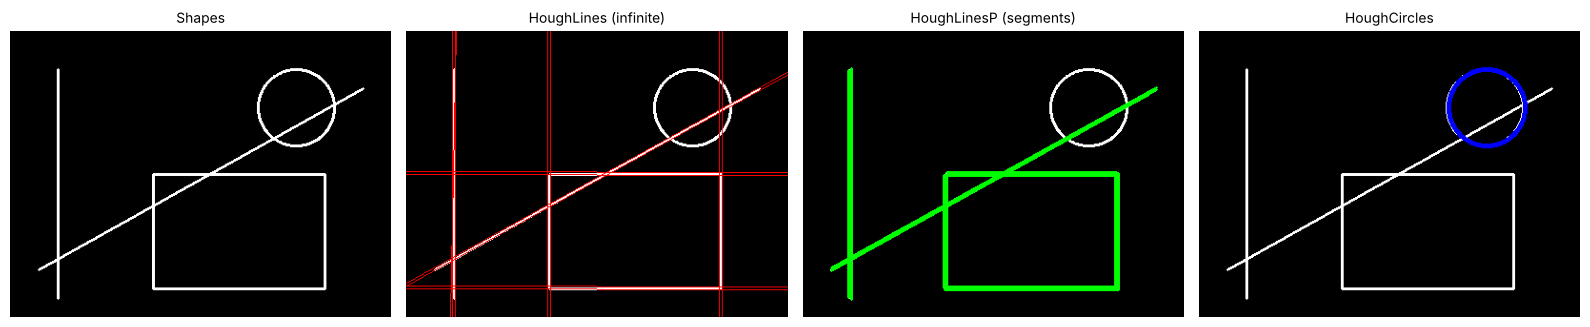

In [5]:
canvas = np.zeros((300, 400, 3), np.uint8)
cv2.line(canvas, (30, 250), (370, 60), (255, 255, 255), 2); cv2.line(canvas, (50, 40), (50, 280), (255, 255, 255), 2); cv2.rectangle(canvas, (150, 150), (330, 270), (255, 255, 255), 2)
cv2.circle(canvas, (300, 80), 40, (255, 255, 255), 2)
edges = cv2.Canny(cv2.cvtColor(canvas, cv2.COLOR_BGR2GRAY), 50, 150)

std = canvas.copy()
lines = cv2.HoughLines(edges, 1, np.pi / 180, 100)                    # (rho, theta) pairs
for rho, theta in lines.reshape(-1, 2):        # reshape works in OpenCV 4 (N,1,2) and 5
    a, b = np.cos(theta), np.sin(theta); x0, y0 = a * rho, b * rho
    cv2.line(std, (int(x0 + 1000 * -b), int(y0 + 1000 * a)), (int(x0 - 1000 * -b), int(y0 - 1000 * a)), (0, 0, 255), 1)
prob = canvas.copy()
segs = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=50, minLineLength=40, maxLineGap=10)   # segments with end points
for x1, y1, x2, y2 in segs.reshape(-1, 4): cv2.line(prob, (x1, y1), (x2, y2), (0, 255, 0), 2)
circ = canvas.copy()
cs = cv2.HoughCircles(cv2.cvtColor(canvas, cv2.COLOR_BGR2GRAY), cv2.HOUGH_GRADIENT, dp=1, minDist=30, param1=100, param2=20, minRadius=20, maxRadius=60)
for x, y, r in np.round(cs.reshape(-1, 3)).astype(int): cv2.circle(circ, (x, y), r, (255, 0, 0), 3)
print(f'HoughLines: {len(lines)} lines | HoughLinesP: {len(segs)} segments | HoughCircles: {len(cs.reshape(-1, 3))} circle(s)')
show([canvas, std, prob, circ], ['Shapes', 'HoughLines (infinite)', 'HoughLinesP (segments)', 'HoughCircles'])

# D. SIFT — Scale-Invariant Feature Transform
1. **Scale-space extrema** via **DoG** = L(x,y,kσ) − L(x,y,σ)  2. **Keypoint localization** (3-D quadratic fit; **26-neighbour** check: 8 + 9 + 9)  3. **Orientation assignment** (dominant gradient → rotation invariance)  4. **Descriptor**: 4×4 sub-regions × 8 bins = **128-D**  5. **Matching** (Euclidean distance)  6. **Outlier rejection – RANSAC**  7. **Homography** estimation.

Number of keypoints: 1113 | Descriptor shape: (1113, 128)
raw matches 1113 -> ratio test 487 -> RANSAC inliers 480


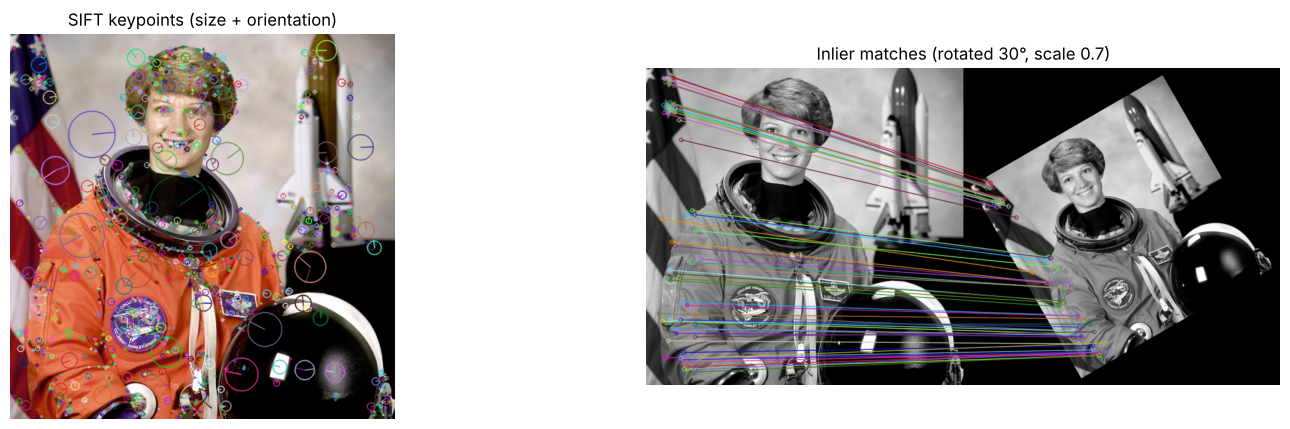

In [6]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(g, None)
image_keypoints = cv2.drawKeypoints(image_rgb, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
print('Number of keypoints:', len(keypoints), '| Descriptor shape:', descriptors.shape)   # (N, 128)

# Matching to a rotated + scaled copy, Lowe ratio test, then RANSAC homography
h, w = g.shape
M = cv2.getRotationMatrix2D((w / 2, h / 2), 30, 0.7)
g2 = cv2.warpAffine(g, M, (w, h))
kp2, des2 = sift.detectAndCompute(g2, None)
matches = cv2.BFMatcher(cv2.NORM_L2).knnMatch(descriptors, des2, k=2)
good = [m for m, n in matches if m.distance < 0.75 * n.distance]          # ratio test
src = np.float32([keypoints[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
H, inliers = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
print(f'raw matches {len(matches)} -> ratio test {len(good)} -> RANSAC inliers {int(inliers.sum())}')
vis = cv2.drawMatches(g, keypoints, g2, kp2, [m for m, k in zip(good, inliers.ravel()) if k][:60], None, flags=2)
fig, ax = plt.subplots(1, 2, figsize=(18, 5))
ax[0].imshow(image_keypoints); ax[0].set_title('SIFT keypoints (size + orientation)'); ax[1].imshow(vis); ax[1].set_title('Inlier matches (rotated 30°, scale 0.7)')
for a in ax: a.axis('off')
plt.show()

# Lab-timing Tasks
## T-A — Computer Screen Detection (Hough Lines)
Pipeline: gray → blur → Canny → **HoughLinesP** → draw lines on a blank mask → close gaps → contours with 4 corners = screen boundaries → **status** from brightness inside (ON/OFF) → **missing** slots from the row/column grid.

Hough segments: 48 (48 horizontal/vertical) | screens found: 7 | ON=5 OFF=2 | missing slots: 1


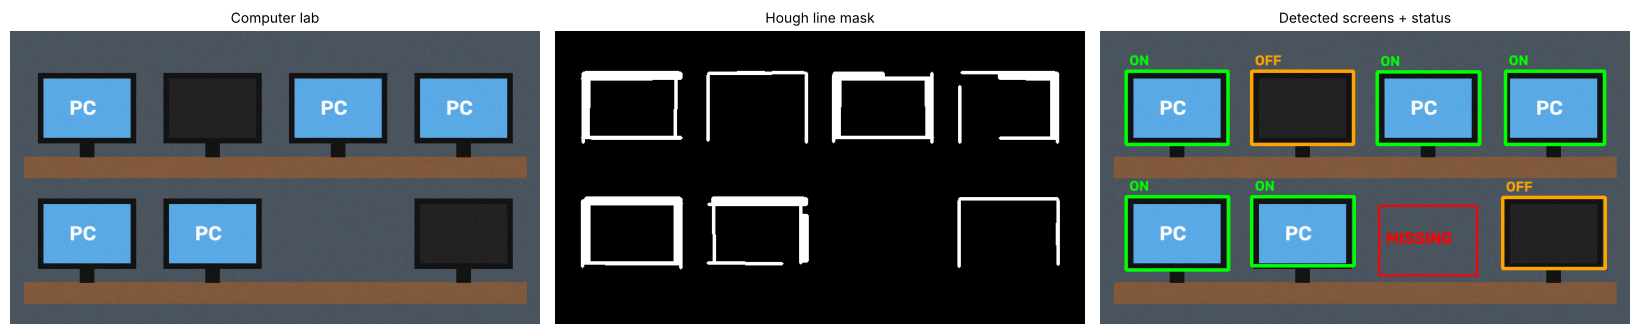

True

In [7]:
def make_lab():
    img = np.full((420, 760, 3), (95, 85, 75), np.uint8)
    status = {}
    for r, y in enumerate([60, 240]):
        cv2.rectangle(img, (20, y + 120), (740, y + 150), (60, 90, 130), -1)                 # desk
        for c, x in enumerate([40, 220, 400, 580]):
            key = (r, c)
            if key == (1, 2): status[key] = 'MISSING'; continue                            # empty slot
            on = key not in [(0, 1), (1, 3)]
            cv2.rectangle(img, (x, y), (x + 140, y + 100), (20, 20, 20), -1)               # bezel
            cv2.rectangle(img, (x + 8, y + 8), (x + 132, y + 92), (230, 170, 90) if on else (35, 35, 35), -1)
            if on: cv2.putText(img, 'PC', (x + 45, y + 60), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
            cv2.rectangle(img, (x + 60, y + 100), (x + 80, y + 120), (20, 20, 20), -1)        # stand
            status[key] = 'ON' if on else 'OFF'
    return np.clip(img + rng.normal(0, 4, img.shape), 0, 255).astype(np.uint8), status
lab, truth = make_lab(); cv2.imwrite('data/computer_lab.png', lab)

lab = cv2.imread('data/computer_lab.png')
g = cv2.GaussianBlur(cv2.cvtColor(lab, cv2.COLOR_BGR2GRAY), (5, 5), 0)
edges = cv2.Canny(g, 30, 100)
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=40, minLineLength=60, maxLineGap=15)
line_mask = np.zeros_like(g)
hv = 0
for x1, y1, x2, y2 in lines.reshape(-1, 4):           # each segment = 2 end points
    ang = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1))) % 180
    if ang < 5 or abs(ang - 90) < 5:                                   # keep horizontal & vertical lines only
        cv2.line(line_mask, (x1, y1), (x2, y2), 255, 3); hv += 1
line_mask = cv2.morphologyEx(line_mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))   # join broken corners
cnts, _ = cv2.findContours(line_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
screens = []
for cnt in cnts:
    x, y, w, h = cv2.boundingRect(cnt)
    if 100 < w < 200 and 70 < h < 140 and 1.1 < w / h < 2.0:            # screen-shaped rectangles
        inner = g[y + 12:y + h - 12, x + 12:x + w - 12]
        screens.append((x, y, w, h, 'ON' if inner.mean() > 80 else 'OFF'))
# expected grid from detected positions -> find missing slots
xs = sorted({round(s[0] / 50) * 50 for s in screens}); ys = sorted({round(s[1] / 50) * 50 for s in screens})
present = {(round(s[1] / 50) * 50, round(s[0] / 50) * 50) for s in screens}
missing = [(y, x) for y in ys for x in xs if (y, x) not in present]

out = lab.copy()
for x, y, w, h, st in screens:
    col = (0, 255, 0) if st == 'ON' else (0, 165, 255)
    cv2.rectangle(out, (x, y), (x + w, y + h), col, 3); cv2.putText(out, st, (x + 5, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, col, 2)
for y, x in missing:
    cv2.rectangle(out, (x, y), (x + 140, y + 100), (0, 0, 255), 2); cv2.putText(out, 'MISSING', (x + 10, y + 55), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
print(f'Hough segments: {len(lines)} ({hv} horizontal/vertical) | screens found: {len(screens)} | ON={sum(s[4]=="ON" for s in screens)} OFF={sum(s[4]=="OFF" for s in screens)} | missing slots: {len(missing)}')
show([lab, line_mask, out], ['Computer lab', 'Hough line mask', 'Detected screens + status'], size=5.5)
cv2.imwrite('output/TA_screens.png', out)

## T-B — Asset Tracking with SIFT (inventory)
Each asset has a **reference image**. For every reference: SIFT match (ratio test) → RANSAC homography → if enough inliers, draw its outline and add to the inventory.

Inventory: {'Monitor': 1, 'Keyboard': 1, 'Mug': 1}


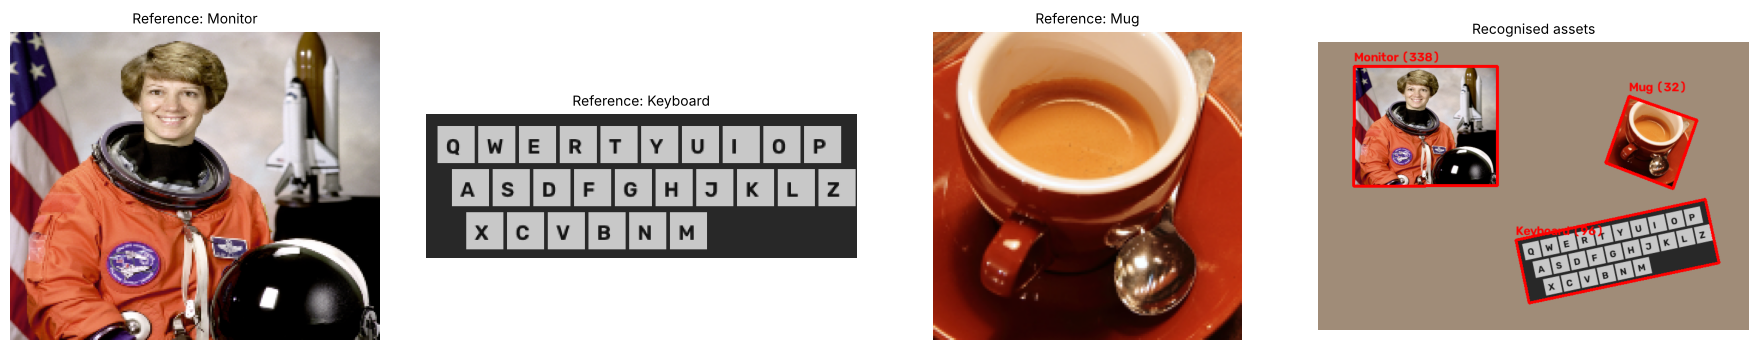

True

In [8]:
def keyboard_img():
    kb = np.full((120, 360, 3), 40, np.uint8)
    keys = 'QWERTYUIOPASDFGHJKLZXCVBNM'
    for i, ch in enumerate(keys):
        r, c = divmod(i, 10); x, y = 10 + c * 34 + r * 12, 10 + r * 36
        cv2.rectangle(kb, (x, y), (x + 30, y + 30), (200, 200, 200), -1); cv2.putText(kb, ch, (x + 7, y + 23), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (20, 20, 20), 2)
    return kb
refs = {'Monitor': cv2.resize(cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR), (240, 200)),
        'Keyboard': keyboard_img(),
        'Mug': cv2.resize(cv2.cvtColor(data.coffee(), cv2.COLOR_RGB2BGR)[50:350, 150:450], (150, 150))}
for k, v in refs.items(): cv2.imwrite(f'data/ref_{k}.png', v)

def place(scene, obj, M3):
    h, w = obj.shape[:2]; H, W = scene.shape[:2]
    warped = cv2.warpPerspective(obj, M3, (W, H)); m = cv2.warpPerspective(np.full((h, w), 255, np.uint8), M3, (W, H))
    scene[m > 0] = warped[m > 0]
scene = np.full((480, 720, 3), (120, 140, 160), np.uint8)
def Tm(tx, ty, ang=0, s=1.0):
    R = np.vstack([cv2.getRotationMatrix2D((0, 0), ang, s), [0, 0, 1]]); R[0, 2] += tx; R[1, 2] += ty; return R
place(scene, refs['Monitor'], Tm(60, 40, 0, 1.0))
place(scene, refs['Keyboard'], Tm(330, 330, 12, 0.9))
place(scene, refs['Mug'], Tm(520, 90, -20, 0.8))
cv2.imwrite('data/lab_desk.png', scene)

sift = cv2.SIFT_create(); bf = cv2.BFMatcher(cv2.NORM_L2)
scene = cv2.imread('data/lab_desk.png'); kp_s, des_s = sift.detectAndCompute(cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY), None)
inventory, out = {}, scene.copy()
for name, ref in refs.items():
    kp_r, des_r = sift.detectAndCompute(cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY), None)
    good = [m for m, n in bf.knnMatch(des_r, des_s, k=2) if m.distance < 0.75 * n.distance]
    if len(good) < 10: inventory[name] = 0; continue
    src = np.float32([kp_r[m.queryIdx].pt for m in good]).reshape(-1, 1, 2); dst = np.float32([kp_s[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, inl = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    h, w = ref.shape[:2]
    box = cv2.perspectiveTransform(np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2), H)
    cv2.polylines(out, [np.int32(box)], True, (0, 0, 255), 3); cv2.putText(out, f'{name} ({int(inl.sum())})', tuple(np.int32(box[0, 0]) + [0, -8]), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    inventory[name] = 1
print('Inventory:', inventory)
show(list(refs.values()) + [out], [f'Reference: {k}' for k in refs] + ['Recognised assets'], cols=4, size=4.5)
cv2.imwrite('output/TB_assets.png', out)

## T-C — Anomaly Detection in Sensor Data (Wavelet)
Wavelet decomposition (db4) → soft-threshold detail coefficients (universal threshold) → inverse = **denoised signal** → **residual = data − denoised** → points with |residual| > k·σ are **anomalies**.

threshold = 2.5 x std = 2.34 | flagged 27 | correct 23/25 injected faults


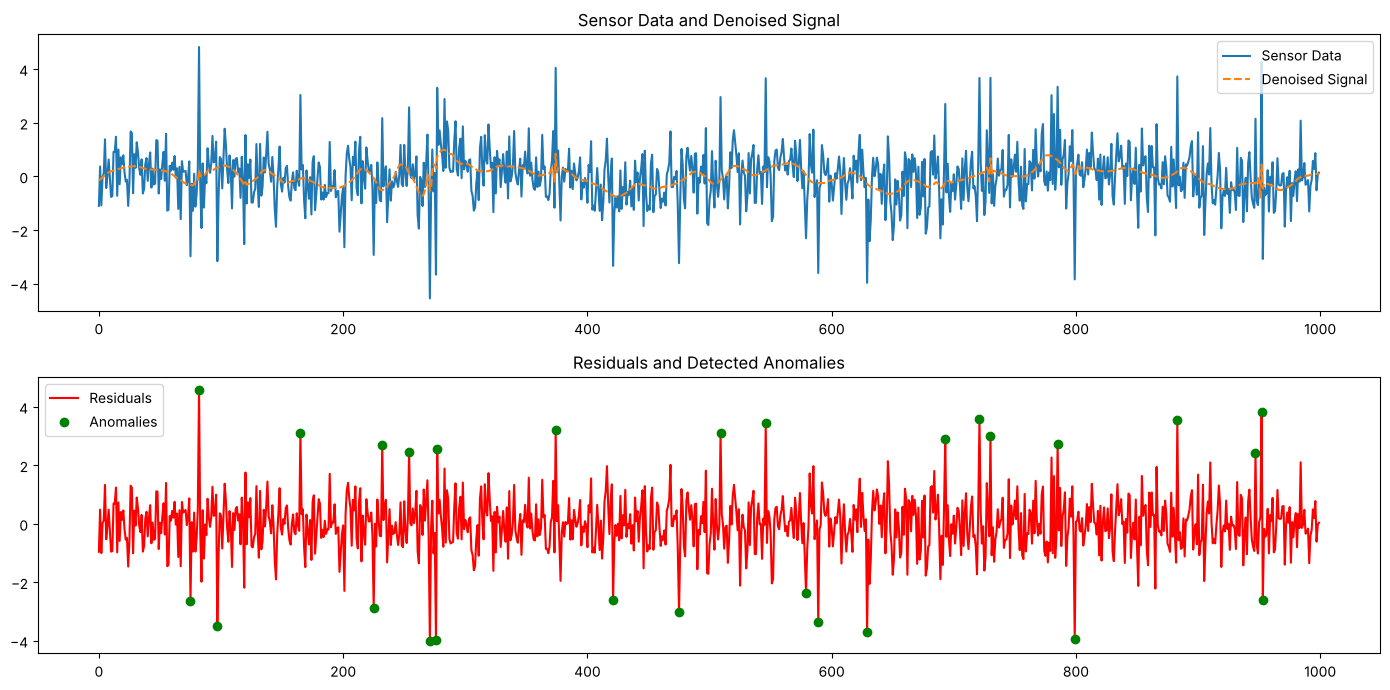

In [9]:
n = 1000
t = np.arange(n)
sensor = 0.3 * np.sin(2 * np.pi * t / 250) + rng.normal(0, 0.8, n)          # normal machine behaviour
true_idx = rng.choice(n, 25, replace=False)
sensor[true_idx] += rng.choice([-1, 1], 25) * rng.uniform(2.5, 4.0, 25)      # injected faults
np.savetxt('data/sensor.csv', sensor, delimiter=',')

data_ = np.loadtxt('data/sensor.csv', delimiter=',')
coeffs = pywt.wavedec(data_, 'db4', level=4)
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
uthr = sigma * np.sqrt(2 * np.log(len(data_)))
den_coeffs = [coeffs[0]] + [pywt.threshold(c, uthr, mode='soft') for c in coeffs[1:]]
denoised = pywt.waverec(den_coeffs, 'db4')[:len(data_)]
residuals = data_ - denoised
k = 2.5
anomalies = np.where(np.abs(residuals - residuals.mean()) > k * residuals.std())[0]
tp = len(set(anomalies) & set(true_idx))
print(f'threshold = {k} x std = {k * residuals.std():.2f} | flagged {len(anomalies)} | correct {tp}/{len(true_idx)} injected faults')

fig, ax = plt.subplots(2, 1, figsize=(14, 7))
ax[0].plot(data_, label='Sensor Data'); ax[0].plot(denoised, '--', label='Denoised Signal'); ax[0].legend(); ax[0].set_title('Sensor Data and Denoised Signal')
ax[1].plot(residuals, 'r', label='Residuals'); ax[1].plot(anomalies, residuals[anomalies], 'go', label='Anomalies'); ax[1].legend(); ax[1].set_title('Residuals and Detected Anomalies')
plt.tight_layout(); plt.savefig('output/TC_anomalies.png'); plt.show()

# Lab Tasks
## T-D — Object Recognition with SIFT (scale, rotation, occlusion) + bounding boxes
`recognize(reference, frame)` works for still images **and** video frames (loop shown below).

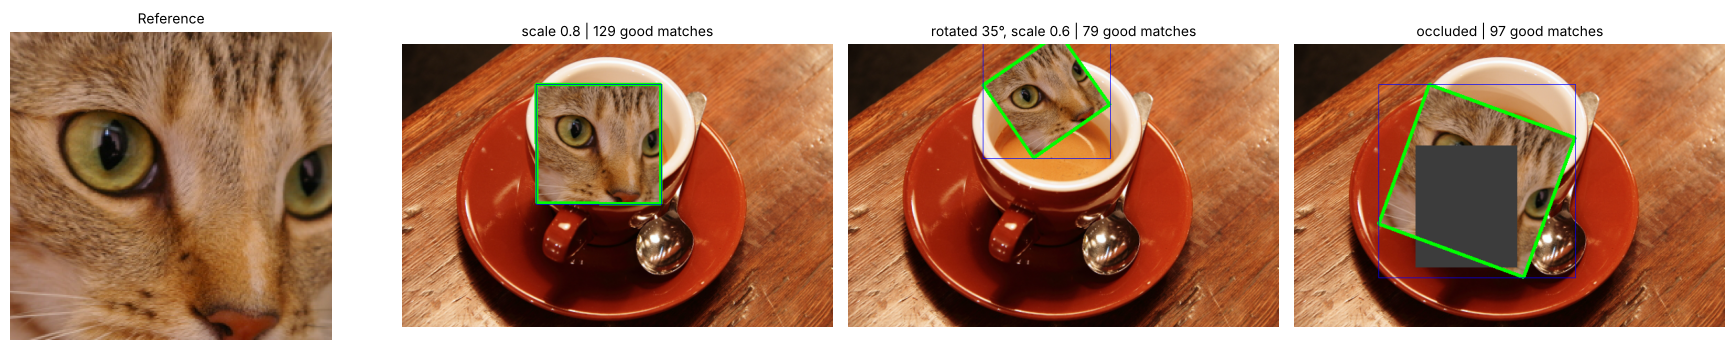

In [10]:
def recognize(ref_bgr, frame_bgr, min_matches=10, ratio=0.75):
    sift = cv2.SIFT_create()
    kp1, d1 = sift.detectAndCompute(cv2.cvtColor(ref_bgr, cv2.COLOR_BGR2GRAY), None)
    kp2, d2 = sift.detectAndCompute(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY), None)
    if d2 is None: return frame_bgr, 0
    good = [m for m, n in cv2.BFMatcher().knnMatch(d1, d2, k=2) if m.distance < ratio * n.distance]
    out = frame_bgr.copy()
    if len(good) < min_matches:
        cv2.putText(out, 'NOT FOUND', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2); return out, len(good)
    src = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2); dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, _ = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    h, w = ref_bgr.shape[:2]
    box = cv2.perspectiveTransform(np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2), H)
    cv2.polylines(out, [np.int32(box)], True, (0, 255, 0), 3)
    x, y, bw, bh = cv2.boundingRect(np.int32(box)); cv2.rectangle(out, (x, y), (x + bw, y + bh), (255, 0, 0), 1)
    return out, len(good)

reference = cv2.cvtColor(data.chelsea(), cv2.COLOR_RGB2BGR)[30:250, 100:330]          # the object (cat face)
bg = cv2.cvtColor(data.coffee(), cv2.COLOR_RGB2BGR)
tests = []
for ang, s, occl in [(0, 0.8, False), (35, 0.6, False), (-20, 1.0, True)]:
    sc = cv2.resize(bg, (640, 420)).copy()
    place(sc, reference, Tm(200, 60, ang, s))
    if occl: cv2.rectangle(sc, (180, 150), (330, 330), (60, 60, 60), -1)                 # partial occlusion
    tests.append(sc)
results = [recognize(reference, t) for t in tests]
show([reference] + [r[0] for r in results], ['Reference'] + [f'{d} | {r[1]} good matches' for d, r in zip(['scale 0.8', 'rotated 35°, scale 0.6', 'occluded'], results)], cols=4, size=4.5)

# Video version (works with cv2.VideoCapture('file.mp4') or 0 for webcam):
# cap = cv2.VideoCapture('data/test_video.mp4')
# while True:
#     ret, frame = cap.read()
#     if not ret: break
#     out, n = recognize(reference, frame)
#     cv2.imshow('Recognition', out)
#     if cv2.waitKey(1) & 0xFF == ord('q'): break
# cap.release(); cv2.destroyAllWindows()

## T-E — Panoramic Image with SIFT (match adjacent images → homography → warp → stitch)

pair 1: 179 matches / 160 inliers | pair 2: 153 matches / 129 inliers | panorama 1001x500


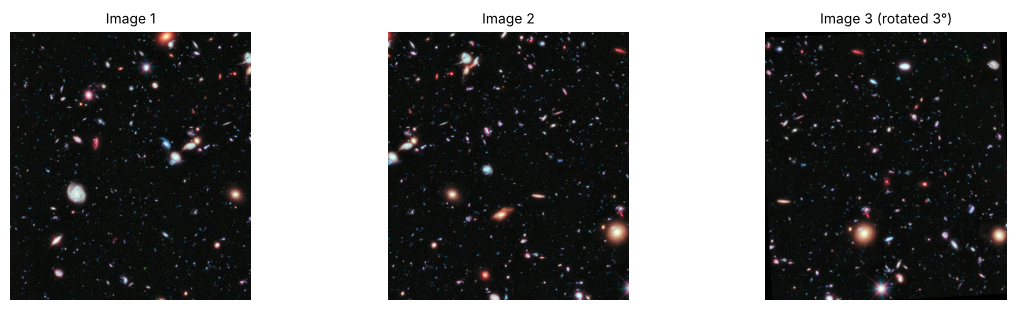

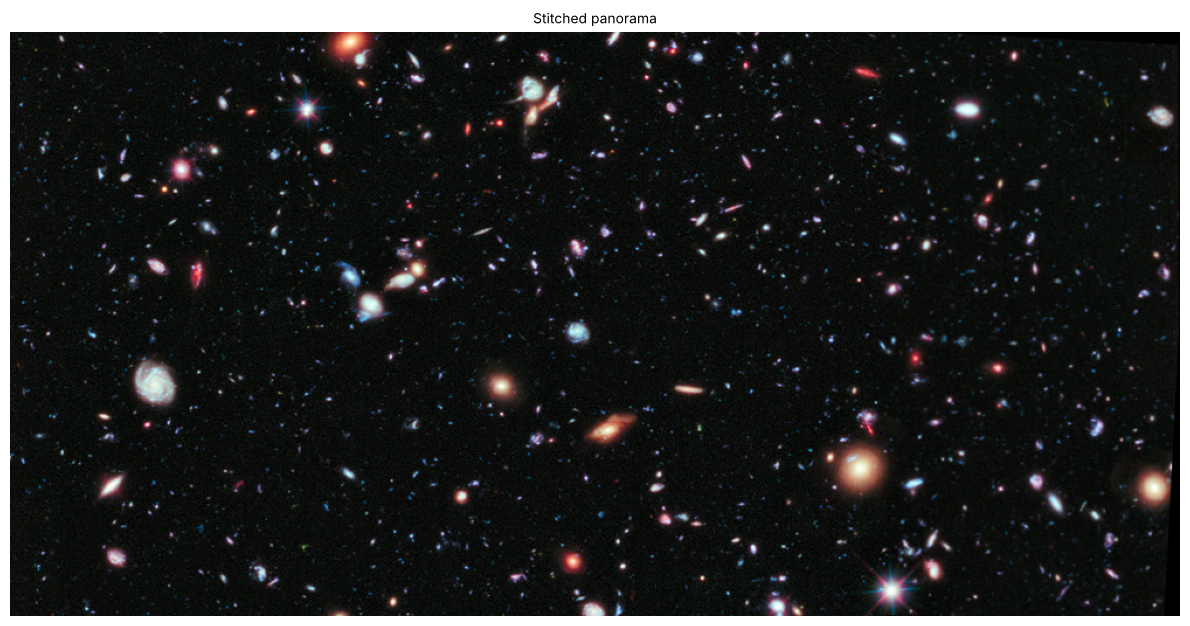

True

In [11]:
wide = cv2.cvtColor(data.hubble_deep_field(), cv2.COLOR_RGB2BGR)[100:600]      # 500 x 1000
parts = [wide[:, 0:450], wide[:, 300:750], wide[:, 550:1000]]                  # overlapping "camera pans"
parts[2] = cv2.warpAffine(parts[2], cv2.getRotationMatrix2D((225, 250), 3, 1.0), (450, 500))   # slight rotation
for i, p in enumerate(parts): cv2.imwrite(f'data/pano_{i}.png', p)

def stitch(left, right, ratio=0.75):
    sift = cv2.SIFT_create()
    kl, dl = sift.detectAndCompute(cv2.cvtColor(left, cv2.COLOR_BGR2GRAY), None)
    kr, dr = sift.detectAndCompute(cv2.cvtColor(right, cv2.COLOR_BGR2GRAY), None)
    good = [m for m, n in cv2.BFMatcher().knnMatch(dr, dl, k=2) if m.distance < ratio * n.distance]
    src = np.float32([kr[m.queryIdx].pt for m in good]).reshape(-1, 1, 2); dst = np.float32([kl[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 4.0)          # right -> left coordinates
    h, w = left.shape[:2]
    pano = cv2.warpPerspective(right, H, (w + right.shape[1], h))
    pano[0:h, 0:w] = np.where(left > 0, left, pano[0:h, 0:w])        # paste left image
    cols = np.where(pano.max(axis=(0, 2)) > 0)[0]                    # crop empty black columns
    return pano[:, :cols[-1] + 1], len(good), int(mask.sum())

pano01, g1, i1 = stitch(parts[0], parts[1])
pano, g2, i2 = stitch(pano01, parts[2])
print(f'pair 1: {g1} matches / {i1} inliers | pair 2: {g2} matches / {i2} inliers | panorama {pano.shape[1]}x{pano.shape[0]}')
show(parts, ['Image 1', 'Image 2', 'Image 3 (rotated 3°)'], size=4)
show([pano], ['Stitched panorama'], size=12)
cv2.imwrite('output/TE_panorama.png', pano)
# One-liner alternative: status, pano = cv2.Stitcher_create().stitch(parts)

## T-F — Lane Detection (Hough Line Transform)
gray → blur → Canny → **ROI mask** (road trapezoid) → **HoughLinesP** → split by slope (left < 0 < right) → average & extrapolate → draw on frame.

left segments: 4 | right segments: 4


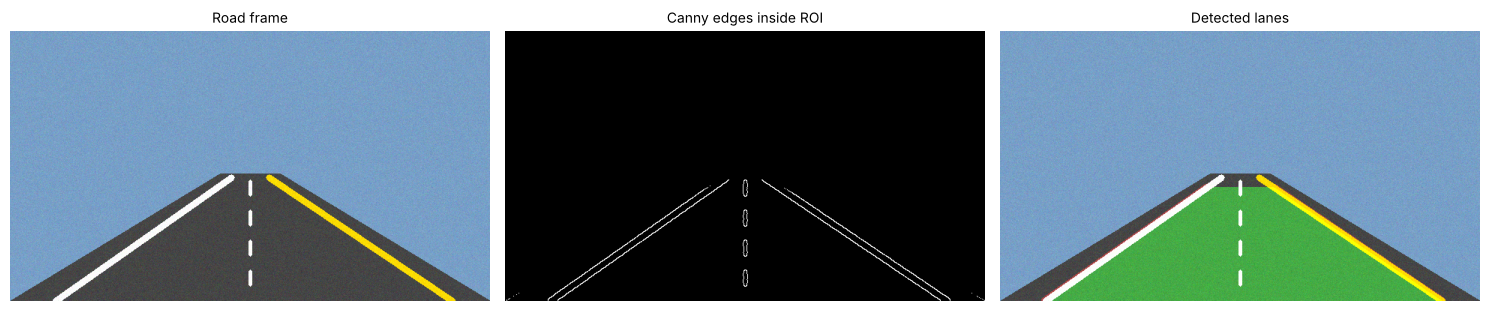

True

In [12]:
road = np.zeros((360, 640, 3), np.uint8); road[:] = (200, 160, 120)                       # sky
cv2.fillPoly(road, [np.int32([[0, 360], [640, 360], [360, 190], [280, 190]])], (70, 70, 70))  # asphalt
cv2.line(road, (60, 360), (295, 195), (255, 255, 255), 8); cv2.line(road, (590, 360), (345, 195), (0, 220, 255), 8)  # lanes
for y in range(200, 360, 40): cv2.line(road, (320, y), (320, y + 18), (255, 255, 255), 3)                            # dashed centre
road = np.clip(road + rng.normal(0, 8, road.shape), 0, 255).astype(np.uint8); cv2.imwrite('data/road.png', road)

def detect_lanes(frame):
    h, w = frame.shape[:2]
    edges = cv2.Canny(cv2.GaussianBlur(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), (5, 5), 0), 50, 150)
    roi = np.zeros_like(edges)
    cv2.fillPoly(roi, [np.int32([[0, h], [w, h], [w * 0.55, h * 0.55], [w * 0.45, h * 0.55]])], 255)
    masked = cv2.bitwise_and(edges, roi)
    lines = cv2.HoughLinesP(masked, 1, np.pi / 180, threshold=40, minLineLength=40, maxLineGap=100)
    left, right = [], []
    for x1, y1, x2, y2 in (lines.reshape(-1, 4) if lines is not None else []):
        if x2 == x1: continue
        slope = (y2 - y1) / (x2 - x1)
        if abs(slope) < 0.4: continue                        # ignore near-horizontal
        (left if slope < 0 else right).append((slope, y1 - slope * x1))
    out = frame.copy(); overlay = np.zeros_like(frame)
    y_bot, y_top = h, int(h * 0.58)
    pts = []
    for group in (left, right):
        if group:
            m, b = np.mean(group, axis=0)                     # average line y = m x + b
            x_b, x_t = int((y_bot - b) / m), int((y_top - b) / m)
            cv2.line(overlay, (x_b, y_bot), (x_t, y_top), (0, 0, 255), 10); pts.append(((x_b, y_bot), (x_t, y_top)))
    if len(pts) == 2:
        cv2.fillPoly(overlay, [np.int32([pts[0][0], pts[0][1], pts[1][1], pts[1][0]])], (0, 255, 0))
    return cv2.addWeighted(out, 1.0, overlay, 0.4, 0), masked, len(left), len(right)

road = cv2.imread('data/road.png')
lane_img, masked, nl, nr = detect_lanes(road)
print(f'left segments: {nl} | right segments: {nr}')
show([road, masked, lane_img], ['Road frame', 'Canny edges inside ROI', 'Detected lanes'], size=5)
cv2.imwrite('output/TF_lanes.png', lane_img)

## T-G — Coin Detection & Counting (Hough Circle Transform)

Coins counted: 24 (ground truth for skimage coins = 24)


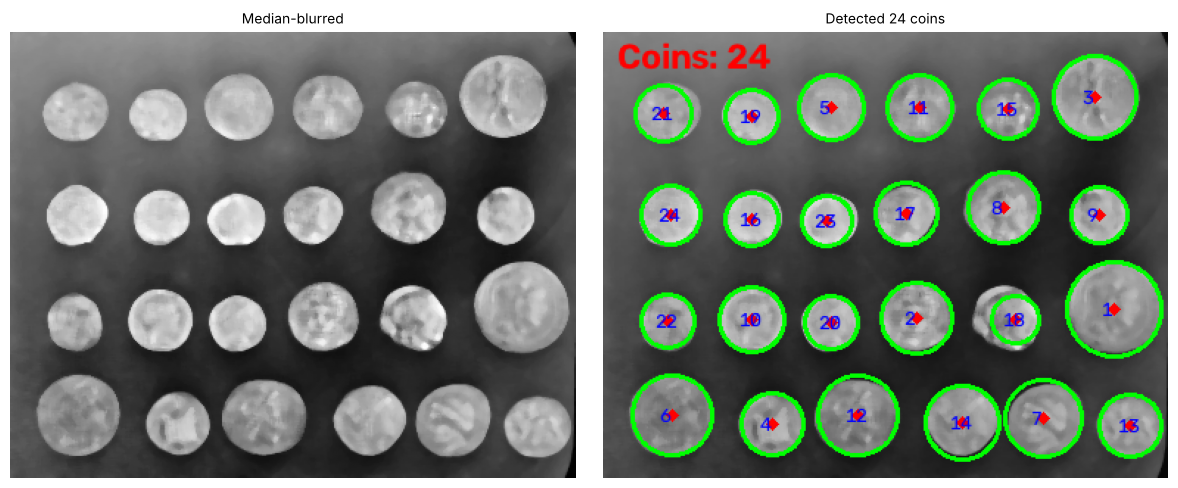

True

In [13]:
coins = cv2.imread('data/coins.png')                    # replace with your coin images
gray_c = cv2.medianBlur(cv2.cvtColor(coins, cv2.COLOR_BGR2GRAY) if coins.ndim == 3 else coins, 5)
circles = cv2.HoughCircles(gray_c, cv2.HOUGH_GRADIENT, dp=1.2, minDist=20,
                           param1=100,          # Canny high threshold
                           param2=30,           # accumulator votes needed (lower = more circles)
                           minRadius=12, maxRadius=40)
out = cv2.cvtColor(gray_c, cv2.COLOR_GRAY2BGR) if gray_c.ndim == 2 else coins.copy()
circles = np.zeros((0, 3)) if circles is None else circles.reshape(-1, 3)   # (x, y, r) rows
count = len(circles)
for i, (x, y, r) in enumerate(np.round(circles).astype(int), 1):
    cv2.circle(out, (x, y), r, (0, 255, 0), 2); cv2.circle(out, (x, y), 2, (0, 0, 255), 3); cv2.putText(out, str(i), (x - 8, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 1)
cv2.putText(out, f'Coins: {count}', (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
print('Coins counted:', count, '(ground truth for skimage coins = 24)')
show([gray_c, out], ['Median-blurred', f'Detected {count} coins'], size=6)
cv2.imwrite('output/TG_coins.png', out)

## T-H — Smart Security System (boundary detection in a zone, real-time video)
Background subtraction (`absdiff` with background frame) → threshold → dilate → **contours = object boundaries** → if a boundary box overlaps the **security zone** → **ALARM**. Set `SHOW_WINDOW = True` on your laptop (or use `cv2.VideoCapture(0)` for a webcam).

frames: 59 | frames with alarm: 19


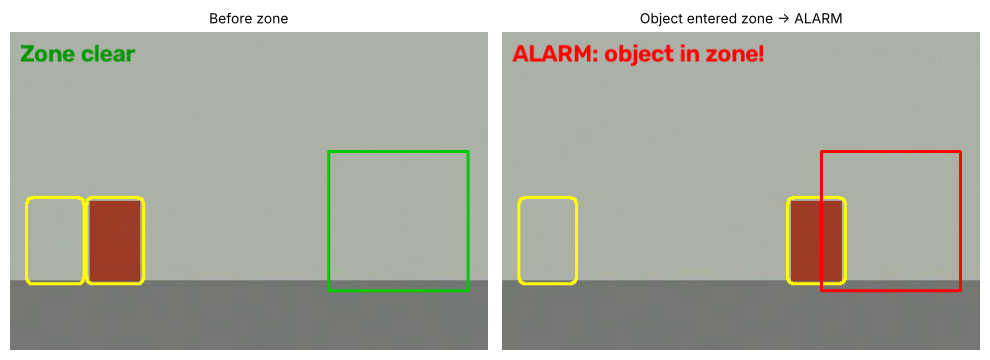

In [14]:
# create a test video: a box slides into the restricted zone
W, H = 480, 320
bgf = np.full((H, W, 3), (170, 180, 175), np.uint8); cv2.rectangle(bgf, (0, 250), (W, H), (120, 120, 120), -1)
vw = cv2.VideoWriter('data/security.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 15, (W, H))
for i in range(60):
    f = bgf.copy(); x = 20 + i * 6
    cv2.rectangle(f, (x, 170), (x + 50, 250), (40, 60, 160), -1)
    vw.write(np.clip(f + rng.normal(0, 3, f.shape), 0, 255).astype(np.uint8))
vw.release()

SHOW_WINDOW = False
ZONE = (320, 120, 460, 260)                                   # x1, y1, x2, y2 security zone
cap = cv2.VideoCapture('data/security.mp4')
ret, background = cap.read()
bg_gray = cv2.GaussianBlur(cv2.cvtColor(background, cv2.COLOR_BGR2GRAY), (21, 21), 0)
snapshots, alarm_frames, n = [], 0, 0
while True:
    ret, frame = cap.read()
    if not ret: break
    n += 1
    gray = cv2.GaussianBlur(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), (21, 21), 0)
    diff = cv2.absdiff(bg_gray, gray)
    _, th = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)
    th = cv2.dilate(th, None, iterations=2)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    alarm = False
    for c in cnts:
        if cv2.contourArea(c) < 500: continue
        cv2.drawContours(frame, [c], -1, (0, 255, 255), 2)                     # object boundary
        x, y, w, h = cv2.boundingRect(c)
        if x < ZONE[2] and x + w > ZONE[0] and y < ZONE[3] and y + h > ZONE[1]:   # rectangle overlap test
            alarm = True
    cv2.rectangle(frame, ZONE[:2], ZONE[2:], (0, 0, 255) if alarm else (0, 200, 0), 2)
    cv2.putText(frame, 'ALARM: object in zone!' if alarm else 'Zone clear', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255) if alarm else (0, 150, 0), 2)
    alarm_frames += alarm
    if SHOW_WINDOW:
        cv2.imshow('Security', frame)
        if cv2.waitKey(30) & 0xFF == ord('q'): break
    elif n in (10, 45):
        snapshots.append(frame.copy()); cv2.imwrite(f'output/TH_frame{n}.png', frame)
cap.release(); cv2.destroyAllWindows()
print(f'frames: {n} | frames with alarm: {alarm_frames}')
show(snapshots, ['Before zone', 'Object entered zone -> ALARM'], size=5)